In [44]:
import anndata as ad

# Read the file
adata = ad.read_h5ad("/home/haitham/mnt/DATA/cart/meta/integration/06_seurat_harmony_t_all_new.h5ad")

/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


AnnData object with n_obs × n_vars = 30559 × 1000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'STUDY', 'WELL', 'WELL_SPLIT', 'lane', 'CD4CD8_BY_EXPRS', 'CD3_BY_EXPRS', 'CAR_BY_EXPRS', 'Perc_of_mito_genes', 'Perc_of_ribosomal_genes', 'log10GenesPerUMI', 'S.Score', 'G2M.Score', 'CellCycle', 'CellCycle_Phase', 'CellCycle_SCORE_UCell', 'T_LIN', 'celltype', 'celltype_short_2', 'celltype_short_3', 'VDJ_T_AVAIL', 'VDJ_B_AVAIL', 'PATIENT_ID', 'SAMPLE_ID', 'TIME_APHERESIS_CAR', 'TIME_CAR_DAY_30', 'TIME_CAR_DAY_100', 'SEX', 'AGE_AT_DIAGNOSIS', 'AGE_AT_CAR', 'TIME_DIAGNOSE_CAR', 'PRODUCT', 'STAGING_SALMON_DURIE', 'R_ISS', 'PROGRESSION_BEFORE_CART', 'STATUS_BEFORE_CAR', 'THERAPY_PRIOR_APHERESIS_GROUP', 'RESPONSE_1_M', 'RESPONSE_3_M', 'RESPONSE_6_M', 'RESPONSE_12_M', 'BEST_RESPONSE', 'BEST_RESPONSE_CONSENSUS', 'PROGRESSION', 'PFS', 'TOCI', 'CRS_GRADE', 'CRS', 'CRS_GROUP', 'ICANS', 'CRP_MAX', 'TIMEPOINT'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_har

In [46]:
# filter low-detection genes
X = ad0.X
if hasattr(X, "toarray"):  # sparse
    frac_expr = np.asarray((X > 0).sum(axis=0)).ravel() / ad0.n_obs
else:
    frac_expr = (X > 0).mean(axis=0)

ad0 = ad0[:, frac_expr >= 0.01].copy()
print("Genes after filtering:", ad0.n_vars)

# HVGs from baseline cells only
sc.pp.highly_variable_genes(ad0, n_top_genes=2000, flavor="seurat")
ad0 = ad0[:, ad0.var["highly_variable"]].copy()
print("Genes after HVG:", ad0.n_vars)

# scale + PCA
sc.pp.scale(ad0, max_value=10)
sc.tl.pca(ad0, n_comps=30)

print("PCA shape:", ad0.obsm["X_pca"].shape)

Genes after filtering: 954
Genes after HVG: 954
PCA shape: (30559, 30)


In [47]:
patient_ids = ad0.obs["PATIENT_ID"].astype(str).values
unique_patients = pd.Index(sorted(pd.unique(patient_ids)))

P = ad0.obsm["X_pca"]

patient_pca = []
for pid in unique_patients:
    idx = np.where(patient_ids == pid)[0]
    patient_pca.append(P[idx].mean(axis=0))

X_patient = pd.DataFrame(
    np.vstack(patient_pca),
    index=unique_patients,
    columns=[f"pc_{i+1}" for i in range(P.shape[1])]
)

print(X_patient.shape)
X_patient.head()

(31, 30)


,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,...,pc_21,pc_22,pc_23,pc_24,pc_25,pc_26,pc_27,pc_28,pc_29,pc_30
0,0.234265,-6.181412,1.961532,-1.517590,-0.188563,1.748986,0.602070,0.083831,0.450250,-0.370676,...,-0.254056,0.132758,0.136187,0.038942,0.038315,-0.193066,0.253699,0.622511,-0.149727,0.039654
1,2.559850,-1.751120,-1.989320,2.944541,1.893837,2.554370,0.941649,-0.910893,-0.603978,-0.444679,...,1.035717,-0.056626,-1.529987,-0.573477,-0.622425,-0.722244,0.042733,-0.644113,0.185848,0.136634
10,-0.428877,0.620808,-1.686087,-1.151345,0.252449,0.506382,0.235192,0.414417,-0.829313,-0.294657,...,-0.140447,-0.564295,0.038473,0.289980,0.123276,-0.101189,0.009486,-0.010340,0.087699,-0.255953
11,2.528031,-7.043314,0.772649,-3.269453,-0.991570,-2.429424,-0.840054,-1.307966,0.316939,0.775049,...,0.549691,0.179802,-0.614687,-0.258918,0.092338,-0.198913,-0.134900,0.206452,0.132712,-0.125437
12,0.604296,-3.005314,1.922053,-0.637402,1.040247,0.549569,-0.146208,0.837371,0.291720,-0.155193,...,-0.363337,-0.039994,-0.033205,0.388390,0.619820,-0.893413,0.315143,0.435472,-0.090281,-0.358909


In [48]:
resp_df = (
    ad0.obs[["PATIENT_ID", "BEST_RESPONSE_CONSENSUS"]]
    .drop_duplicates()
    .copy()
)
resp_df["PATIENT_ID"] = resp_df["PATIENT_ID"].astype(str)
resp_df["y_response"] = pd.to_numeric(resp_df["BEST_RESPONSE_CONSENSUS"], errors="coerce")
resp_df = resp_df[["PATIENT_ID", "y_response"]].dropna().drop_duplicates("PATIENT_ID")

df_resp = X_patient.join(resp_df.set_index("PATIENT_ID"), how="inner")

print("Patients with labels:", len(df_resp))
print(df_resp["y_response"].value_counts())

X = df_resp.drop(columns="y_response")
y = df_resp["y_response"].astype(int)

clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pred_prob = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

auc = roc_auc_score(y, pred_prob)
auprc = average_precision_score(y, pred_prob)

print("AUROC:", round(auc, 3))
print("AUPRC:", round(auprc, 3))

Patients with labels: 31
y_response
1    19
0    12
Name: count, dtype: int64
AUROC: 0.43
AUPRC: 0.584


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

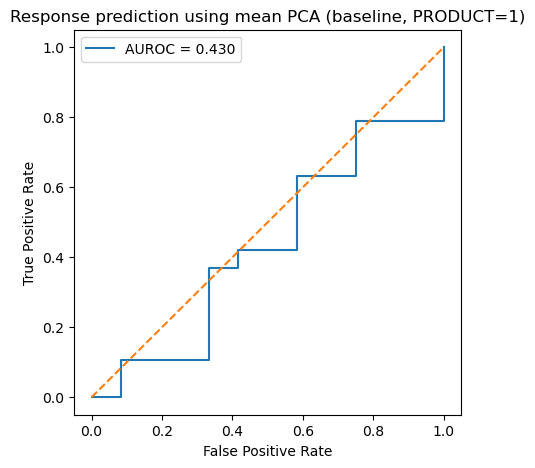

In [49]:
fpr, tpr, _ = roc_curve(y, pred_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Response prediction using mean PCA (baseline, PRODUCT=1)")
plt.legend()
plt.show()

In [32]:
# Baseline only
ad = raw_adata[raw_adata.obs["TIMEPOINT"] == 0].copy()

ad = raw_adata[raw_adata.obs["PRODUCT"] == 1].copy()
print(ad)
print("Patients:", ad.obs["PATIENT_ID"].nunique())
print("Samples:", ad.obs["SAMPLE_ID"].nunique())

response_col = "BEST_RESPONSE_CONSENSUS"
# response_col = "BEST_RESPONSE"

resp_preview = ad.obs[["PATIENT_ID", response_col]].drop_duplicates()
print("\nResponse labels:")
print(resp_preview[response_col].value_counts(dropna=False))

AnnData object with n_obs × n_vars = 95471 × 1000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'STUDY', 'WELL', 'WELL_SPLIT', 'lane', 'CD4CD8_BY_EXPRS', 'CD3_BY_EXPRS', 'CAR_BY_EXPRS', 'Perc_of_mito_genes', 'Perc_of_ribosomal_genes', 'log10GenesPerUMI', 'S.Score', 'G2M.Score', 'CellCycle', 'CellCycle_Phase', 'CellCycle_SCORE_UCell', 'T_LIN', 'celltype', 'celltype_short_2', 'celltype_short_3', 'VDJ_T_AVAIL', 'VDJ_B_AVAIL', 'PATIENT_ID', 'SAMPLE_ID', 'TIME_APHERESIS_CAR', 'TIME_CAR_DAY_30', 'TIME_CAR_DAY_100', 'SEX', 'AGE_AT_DIAGNOSIS', 'AGE_AT_CAR', 'TIME_DIAGNOSE_CAR', 'PRODUCT', 'STAGING_SALMON_DURIE', 'R_ISS', 'PROGRESSION_BEFORE_CART', 'STATUS_BEFORE_CAR', 'THERAPY_PRIOR_APHERESIS_GROUP', 'RESPONSE_1_M', 'RESPONSE_3_M', 'RESPONSE_6_M', 'RESPONSE_12_M', 'BEST_RESPONSE', 'BEST_RESPONSE_CONSENSUS', 'PROGRESSION', 'PFS', 'TOCI', 'CRS_GRADE', 'CRS', 'CRS_GROUP', 'ICANS', 'CRP_MAX', 'TIMEPOINT'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_har

In [33]:
# Filter genes expressed in at least 1% of cells
X = ad.X
if sp.issparse(X):
    frac_expr = np.asarray((X > 0).sum(axis=0)).ravel() / ad.n_obs
else:
    frac_expr = (X > 0).mean(axis=0)

ad = ad[:, frac_expr >= 0.01].copy()
print("Genes kept:", ad.n_vars)

# Mean expression per patient
patient_ids = ad.obs["PATIENT_ID"].astype(str).values
unique_patients = pd.Index(sorted(pd.unique(patient_ids)))
gene_names = ad.var_names.astype(str)

patient_expr = []
for pid in unique_patients:
    idx = np.where(patient_ids == pid)[0]
    Xi = ad.X[idx]
    mean_vec = np.asarray(Xi.mean(axis=0)).ravel() if sp.issparse(Xi) else Xi.mean(axis=0)
    patient_expr.append(mean_vec)

patient_expr = pd.DataFrame(
    np.vstack(patient_expr),
    index=unique_patients,
    columns=gene_names
)

# # Cell-type proportions
# celltype_col = "celltype_short_3"  # can switch to celltype_short_2 or celltype
# comp = (
#     ad.obs[["PATIENT_ID", celltype_col]]
#     .assign(n=1)
#     .pivot_table(index="PATIENT_ID", columns=celltype_col, values="n", aggfunc="sum", fill_value=0)
# )
# comp = comp.div(comp.sum(axis=1), axis=0)
# comp.columns = [f"prop_{c}" for c in comp.columns]

# Combine features
# X_patient = patient_expr.join(comp, how="left")
# X_patient.index = X_patient.index.astype(str)

# print("Patient feature matrix:", X_patient.shape)

X_patient = patient_expr
    
X_patient.head()

Genes kept: 947


,ISG15,TNFRSF18,TNFRSF4,ACOT7,TNFRSF9,ENO1,SRM,EFHD2,HNRNPR,TCEA3,...,PGK1,CYSLTR1,ITM2A,BEX3,TCEAL4,SLC25A5,HPRT1,LINC00892,CD40LG,HMGB3
0,-0.130096,0.509396,0.642213,-0.095637,-0.069658,-0.036688,-0.009714,-0.694868,-0.049986,0.400412,...,0.015714,0.240865,0.157339,0.500892,0.362315,0.149638,0.042621,0.077819,0.361594,0.157192
1,-0.095064,0.183156,0.306886,0.106732,0.054973,0.082329,0.065621,-0.479866,0.027609,0.007799,...,0.040665,0.077247,0.149693,0.144875,0.262184,0.177058,0.088203,0.091779,0.068920,0.131299
10,0.328066,0.164480,0.148666,0.084015,-0.117344,0.244065,0.062528,0.214623,0.144139,-0.025666,...,0.170919,-0.073365,0.191223,0.053256,-0.017388,0.225442,0.100232,-0.050744,-0.102268,-0.016522
11,1.260806,0.068402,0.442868,-0.068140,-0.123952,0.145492,0.054910,-0.451583,0.014016,0.354456,...,0.113738,0.251581,0.237963,0.577201,0.319931,-0.112659,-0.053227,0.114375,0.414056,0.080058
12,-0.321761,0.151077,0.374932,-0.040874,0.051121,0.142609,0.122485,-0.256324,0.006330,0.028412,...,0.057007,0.064590,-0.475879,0.138278,0.135777,-0.017160,0.049157,-0.004054,0.033381,-0.025723


In [34]:
X_patient.shape

(32, 947)

Patients with response label: 32
y_response
1    19
0    13
Name: count, dtype: int64
Response AUROC: 0.543
Response AUPRC: 0.65


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

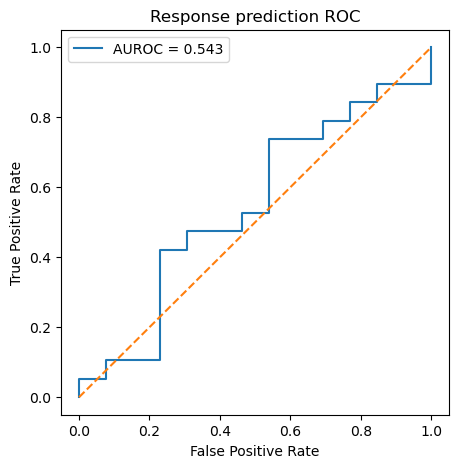

In [35]:
# Patient-level response label
resp_df = (
    ad.obs[["PATIENT_ID", response_col]]
    .drop_duplicates()
    .copy()
)
resp_df["PATIENT_ID"] = resp_df["PATIENT_ID"].astype(str)
resp_df["y_response"] = pd.to_numeric(resp_df[response_col], errors="coerce")
resp_df = resp_df[["PATIENT_ID", "y_response"]].dropna().drop_duplicates("PATIENT_ID")

df_resp = X_patient.join(resp_df.set_index("PATIENT_ID"), how="inner")
print("Patients with response label:", df_resp.shape[0])
print(df_resp["y_response"].value_counts())

# Keep top variable genes + composition features
prop_cols = [c for c in df_resp.columns if c.startswith("prop_")]
gene_cols = [c for c in df_resp.columns if c not in prop_cols + ["y_response"]]

top_genes = df_resp[gene_cols].var(axis=0).sort_values(ascending=False).head(300).index.tolist()
feature_cols = top_genes + prop_cols

X_resp = df_resp[feature_cols]
y_resp = df_resp["y_response"].astype(int)

clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pred_prob = cross_val_predict(clf, X_resp, y_resp, cv=cv, method="predict_proba")[:, 1]

auc = roc_auc_score(y_resp, pred_prob)
auprc = average_precision_score(y_resp, pred_prob)
print("Response AUROC:", round(auc, 3))
print("Response AUPRC:", round(auprc, 3))

# ROC plot
fpr, tpr, _ = roc_curve(y_resp, pred_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Response prediction ROC")
plt.legend()
plt.show()

In [36]:
print(ad.obs[["PATIENT_ID", "PRODUCT", "BEST_RESPONSE_CONSENSUS"]].drop_duplicates()["PRODUCT"].value_counts())
print(
    ad.obs[["PATIENT_ID", "PRODUCT", "BEST_RESPONSE_CONSENSUS"]]
    .drop_duplicates()
    .groupby("PRODUCT")["BEST_RESPONSE_CONSENSUS"]
    .value_counts()
)

PRODUCT
1    32
Name: count, dtype: int64
PRODUCT  BEST_RESPONSE_CONSENSUS
1        1                          19
         0                          13
Name: count, dtype: int64
